# Actividad 4: M2003B
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)

## Instrucciones:
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor


In [24]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2, t, kstest, shapiro
import pandas as pd
data = pd.read_csv('../Data/linear_data.csv')
X = data['X']
Y = data['Y']


##
## 1. Preliminares estadísticas


### 1.0 Distribución del estimador de $\hat{\sigma}^2$
**Ejercicio**: Demuestre numéricamente que la suma de los cuadrados de variables normales independientes sigue una chi2. Complete el código siguiente:



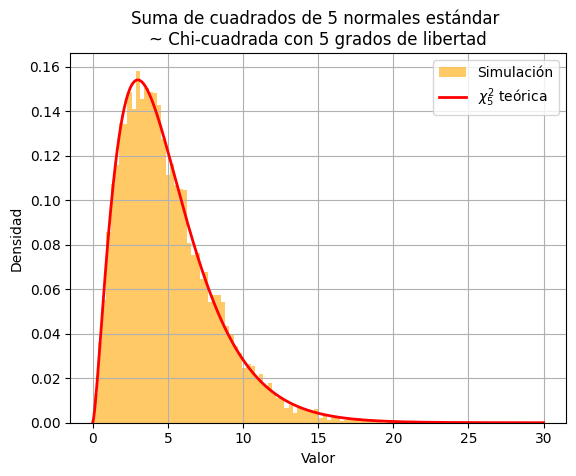

In [5]:
n_samples = 10000
k = 5 # número de normales estándar

# generar k variables normales estándar por simulación
normals = np.random.randn(n_samples, k)

# calcular suma de cuadrados de cada fila
sum_of_squares = np.square(normals).sum(axis=1)

# 3. Comparar con la distribución chi-cuadrada teórica
x = np.linspace(0, 30, 500)
plt.hist(sum_of_squares, bins=100, density=True, alpha=0.6, color='orange', label='Simulación')
plt.plot(x, chi2.pdf(x, df=k), 'r-', lw=2, label=r'$\chi^2_5$ teórica')
plt.title(f'Suma de cuadrados de {k} normales estándar \n~ Chi-cuadrada con {k} grados de libertad')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

### 1.1 Distribuciones Student-t
**Ejercicio**: Demuestre numéricamente que la razón de una distribución Gaussiana y una distribución $\chi^2$ da como resultado una distribución Student-t. Aségurese que la distribución que esta construyendo cumple con lo anterior usanda la prueba estadística de Kolmogorov-Smirnov.

In [ ]:
def student_t_distribution_check(num_samples=10000, n=10):
    """
    Esta función toma el número de samples y la cantidad de observaciones para gegnerar una distribución de t student con grados de libertad n-2

    num_samples: int -> cantidad de muestras

    n: int -> numero de oservaciones
    
    """
    # calcular el # grado de libertad n para la t-distribution
    nu = n - 2

    # generar una muestra para una distribucion normal estandar
    X = np.random.standard_normal(num_samples)

    # generar muestras para una distribucion chi2 con (n-2) grados de libertad
    # [Sugerencia: np.random.chisquare()]
    Y = np.random.chisquare(nu,num_samples)

    # calcular la cantidad pivotal t student
    # [Sugerencia: use definicion vista en clase]
    T = (X)/np.sqrt(Y/nu)

    # ajustar una distribucion a t-distribution a la cantidad T
    # [Sugerencia: t.fit()]
    t_shape, t_loc, t_scale = t.fit(T)

    # realizar la prueba estadistica KS
    # [Sugerencia: kstest()]
    D, p_value = kstest(T,'t', args = (t_shape,t_loc, t_scale))

    # graficar el histograma
    plt.figure(figsize=(8, 6))
    count, bins, _ = plt.hist(T, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='Ratio of N(0,1) and Chi-squared')

    # graficar la funcion ajustada
    x = np.linspace(-5, 5, 100)
    p = t.pdf(x, t_shape, loc=t_loc, scale=t_scale)  # PDF of the fitted t-distribution
    plt.plot(x, p, 'k', linewidth=2, label=f'Fitted t-Distribution\n $\nu={t_shape:.2f}$')

    # nombres
    plt.title(f'Ratio of Standard Normal and Chi-squared Distribution\nSample Size: {num_samples} (ν={nu})')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    # imrprimir numero degrados de libertad y el p-value
    print(f"Estimated degrees of freedom: {t_shape:.2f}")
    print(f"KS test p-value: {p_value:.5f}")

    # inteprete con mensajes el p-value
    if p_value > 0.05:
        print("No se rechaza la hipótesis nula: los datos si siguen la distribución t de student")
    else:
        print("Se rechaza la hhipótesis nula: los datos no siguen la distribución t de student")

### Pruebe su función

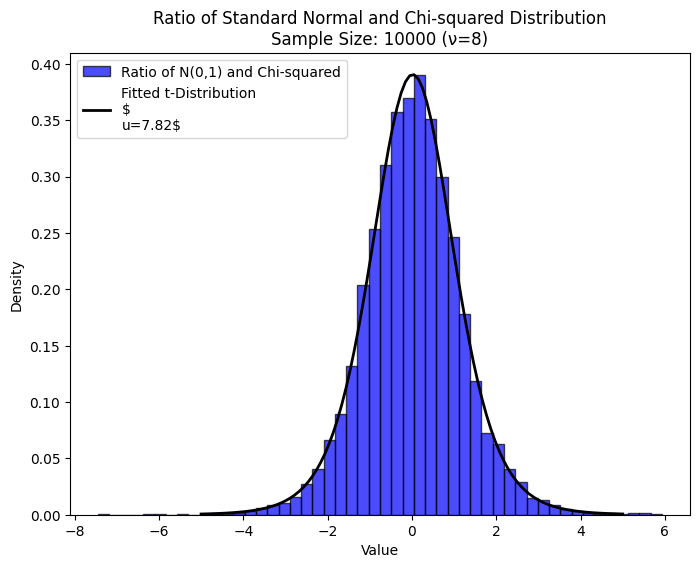

Estimated degrees of freedom: 7.82
KS test p-value: 0.79427
No se rechaza la hipótesis nula: los datos si siguen la distribución t de student


In [17]:
# escriba aquí su código
student_t_distribution_check()

### 1.2 Valores críticos de la estadística-t

**Ejercicio**: Complete la siguiente función que obtiene el valor critico de la distribución Student-t para n-2 grados de libertad.

In [18]:
def critical_t_values(alpha, n):
    """
    Esta función genera los percentiles 1-alpha de una distribución t de estudent con ggradoos de libertad n-2

    alpha: float -> valor de siggnificancia (0,1)  

    n: int -> número de observaciones
    """
    # calcular el numero de grados de libertad
    df = n-2
    
    # obtener los valores t criticos para una prueba de dos colas Get the critical t
    # [Sugerencia: stats.t.ppf()]
    t_critical =  t.ppf(1-alpha, df)

    return t_critical

### Pruebe su función

In [19]:
alpha = 0.05
n = 10  # tamaño de la muestra
critical_value = critical_t_values(alpha, n)
print(f"Critical t-values for alpha={alpha} and n={n}: {critical_value}")

Critical t-values for alpha=0.05 and n=10: 1.8595480375228424


### 1.3 Cantidad pivotal
Una cantidad pivotal es una función que depende de los parámetros de otra distribución dada. Además, la distribución de esta cantidad está libre de parámetros desconocidos. Por ejemplo tenemos la función
$$z=\frac{x-\mu}{\sigma},$$
cuya distribución es una normal con $\mu=0, \sigma=1$.


**Ejercicio:** Utilizando la cantidad pivotal anterior, demuestre que su distribución es Gaussiana con $\mu=0, \sigma=1$. Use la prueba de Shapiro-Wilk para completar su demostración.

In [22]:
def gaussian_pivotal(mean, std_dev, num_samples):
    """
    Función para demostraar que Z ~ N(0,1)

    mean: float -> media de la distribución

    std_dev: float -> desviación estándard de la distribución

    num_samples: int -> cantidad de muestras para la distribución
    """
    # distribuciones gaussianas
    samples = np.random.normal(loc = mean, scale = std_dev, size = num_samples)

    # COMENTAR AQUI
    sample_mean = samples.mean()
    sample_std_dev = samples.std()

    # encontrar la cantidad pivotal (distribucion standard normal)
    # [Sugerencia: use la teoria vista en clase ]
    pivotal_quantity = (samples -sample_mean)/sample_std_dev

    # realizar la prueba Shapiro-Wilk para normalidad
    # [Sugerencia: shapiro() ]
    stat, p_value = shapiro(pivotal_quantity)

    # intepretar 
    alpha = 0.05  # nivel de significancia
    if p_value > alpha:
        interpretation = "los datos se distribuyen normal con media 0 y desviación estándard 1"
    else:
        interpretation = "los datos no se distribuyen normal con media 0 y desviación estándard 1"

    # graficar histos
    plt.figure(figsize=(12, 6))

    # graficar la distro gaussiana originaL
    plt.hist(samples, bins=30, density=True, alpha=0.6, color='b', label='Original Gaussian')
    plt.text(0.05, 0.95, f'Mean={sample_mean:.4f}\nStd={sample_std_dev:.4f}', 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', color='blue')

    # graficar la cantidad pivotal
    plt.hist(pivotal_quantity, bins=30, density=True, alpha=0.6, color='r', label='Pivotal Quantity')
    plt.text(0.7, 0.95, f'Shapiro-Wilk p-value={p_value:.4f}\n{interpretation}', 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', color='red')

    plt.title('Original Gaussian vs. Pivotal Quantity')
    plt.xlabel('Value')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # interpretar el valor p
    print(interpretation)

/opt/anaconda3/envs/mv-tec/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


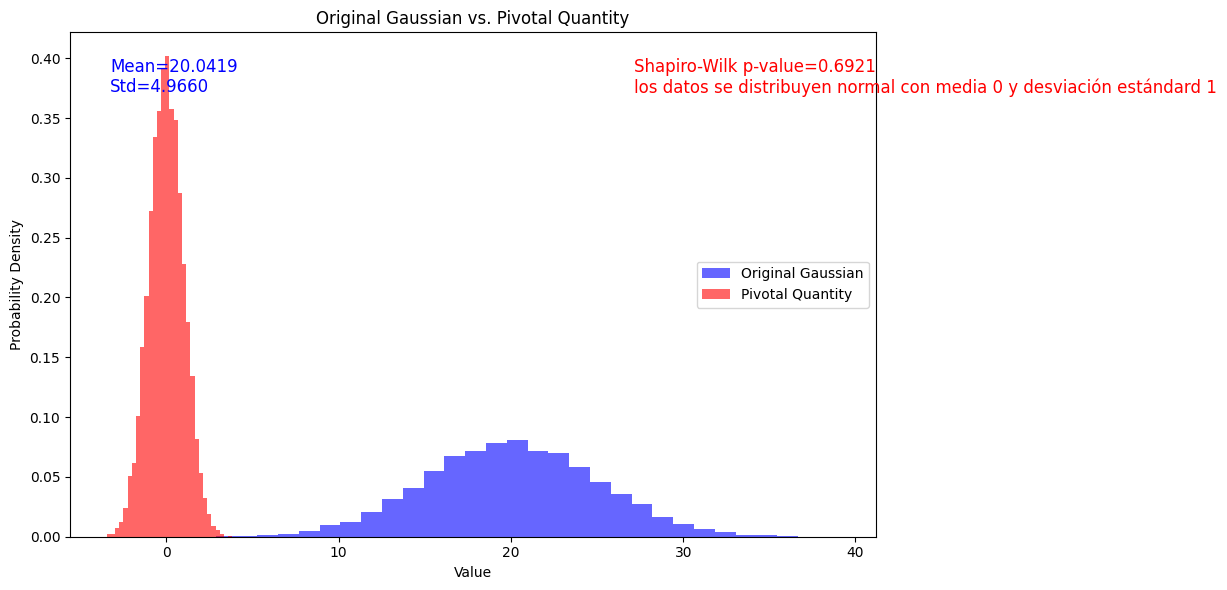

los datos se distribuyen normal con media 0 y desviación estándard 1


In [23]:
gaussian_pivotal(20,5,10000)

## 2. Inferencia en el modelo RL
### 2.1 Intervalos de confianza
 Con las distribuciones de nuestros estimadores tenemos la posibilidad de construir intervalos de confianza. Esto se hace habitualmente con cantidades pivotales, en particular con la estadística T.

**Ejercicio:** Demuestre numéricamente, que las estadísticas T para los estimadores $\beta_0, \beta_1$ siguen distribuciones $t_{n-2}$.

 *Sugerencia:* use la(s) funciones de la primera parte de este tutorial y de los tutoriales anteriores

**Ejercicio:** Encuentre los intervalos de confianza de $\beta_0, \beta_1$

In [30]:

def simple_linear_regression(x, y):
    """
    Ajusta una regresión lineal simple y devuelve los estimadores de
    beta_0 (intersección), beta_1 (pendiente) y sigma (desviación estándar de los errores).
    """
    x = np.array(x)
    y = np.array(y)
    
    x_mean = x.mean()
    y_mean = y.mean()
    
    numerator = np.sum(x*y) - len(x)*x_mean*y_mean
    denominator = np.sum(np.square(x)) - len(x)*np.square(x_mean) 
    beta_1_estimador = numerator/denominator
    beta_0_estimador = y_mean - beta_1_estimador*x_mean

    y_hat = beta_0_estimador + beta_1_estimador*x
    residuals = y - y_hat
    
    n = len(x)
    sigma_estimador = np.sqrt(np.sum(np.square(residuals))/(n-2))
    
    return beta_0_estimador, beta_1_estimador, sigma_estimador

def calculate_standard_errors(x, sigma_hat):
    """
    Calcula los errores estándar de los estimadores beta_0 y beta_1.
    """
    x = np.array(x)
    x_mean = x.mean()
    n = len(x)
    
    se_beta_1 = sigma_hat / np.sqrt(np.sum((x - x_mean)**2))
    se_beta_0 = sigma_hat * np.sqrt(1/n + (x_mean**2)/np.sum((x - x_mean)**2))
    
    return se_beta_0, se_beta_1

def generate_distributions(mean1, std1, mean2, std2, num_samples=1000):
    """
    Genera dos distribuciones normales y una chi-cuadrada.
    """
    gaussian1 = np.random.normal(loc=mean1, scale=std1, size=num_samples)
    gaussian2 = np.random.normal(loc=mean2, scale=std2, size=num_samples)
    
    nu = num_samples - 2
    chi2_dist = np.random.chisquare(df=nu, size=num_samples)

    return gaussian1, gaussian2, chi2_dist


# === USO ===
beta_0_estimador, beta_1_estimador, sigma_estimador = simple_linear_regression(X, Y)
se_beta_0, se_beta_1 = calculate_standard_errors(X, sigma_estimador)
dist1, dist2, dist3 = generate_distributions(beta_0_estimador, se_beta_0, beta_1_estimador, se_beta_1, 10000)

# Distribución T
T1 = (beta_1_estimador - beta_1_estimador) / se_beta_1
T0 = (beta_0_estimador - beta_0_estimador) / se_beta_0

# ajustar una distribucion a t-distribution a la cantidad T
# [Sugerencia: t.fit()]
t_shape, t_loc, t_scale = t.fit(T1)

# realizar la prueba estadistica KS
# [Sugerencia: kstest()]
D, p_value = kstest(T1,'t', args = (t_shape,t_loc, t_scale))

# imrprimir numero degrados de libertad y el p-value
print(f"Estimated degrees of freedom beta 1: {t_shape:.2f}")
print(f"KS test beta 1 p-value: {p_value:.5f}")

# inteprete con mensajes el p-value
if p_value > 0.05:
    print("No se rechaza la hipótesis nula: el estadístico de prueba de beta 1 si sigue la distribución t de student")
else:
    print("Se rechaza la hhipótesis nula: el estadístico de prueba de beta 1 no sigue la distribución t de student")

# ajustar una distribucion a t-distribution a la cantidad T
# [Sugerencia: t.fit()]
t_shape, t_loc, t_scale = t.fit(T0)

# realizar la prueba estadistica KS
# [Sugerencia: kstest()]
D, p_value = kstest(T0,'t', args = (t_shape,t_loc, t_scale))

# imrprimir numero degrados de libertad y el p-value
print(f"Estimated degrees of freedom beta 0: {t_shape:.2f}")
print(f"KS test beta 0 p-value: {p_value:.5f}")

# inteprete con mensajes el p-value
if p_value > 0.05:
    print("No se rechaza la hipótesis nula: el estadístico de prueba de beta 0 si sigue la distribución t de student")
else:
    print("Se rechaza la hhipótesis nula: el estadístico de prueba de beta 0 no sigue la distribución t de student")


Estimated degrees of freedom beta 1: 1.99
KS test beta 1 p-value: 0.58753
No se rechaza la hipótesis nula: el estadístico de prueba de beta 1 si sigue la distribución t de student
Estimated degrees of freedom beta 0: 1.99
KS test beta 0 p-value: 0.58753
No se rechaza la hipótesis nula: el estadístico de prueba de beta 0 si sigue la distribución t de student


In [31]:
# INSERTE SU CODIGO AQUI
print(f'b1 = ({beta_1_estimador: .2f} ± {critical_t_values(0.05, len(X))*se_beta_1}) con 95% de confianza')
print(f'b0 = ({beta_0_estimador: .2f} ± {critical_t_values(0.05, len(X))*se_beta_0}) con 95% de confianza')

b1 = (-2.01 ± 0.017489983168030566) con 95% de confianza
b0 = ( 5.26 ± 0.4155615124948098) con 95% de confianza
